# L602 - Paramter and Parameter Tuning: Solving N-Queens with an Evolutionary Algorithm Framework

**Framework:** [DEAP](https://deap.readthedocs.io/)  
**Problem:** N-Queens
**Course:** CS 5660

A framework such as DEAP, a novel evolutionary computation framework for rapid prototyping and testing our ideas, supplies the algorithm machinery. In this direction, we only need to define the problem-specific representation, such as fitness function, and operators.


In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter
import itertools

# from matplotlib.colors import ListedColormap
import pandas as pd

from utils import draw_board
from ea import fitnessFunction, count_diagonal_attacks, run_n_queens_ea

print("DEAP is ready.")

DEAP is ready.


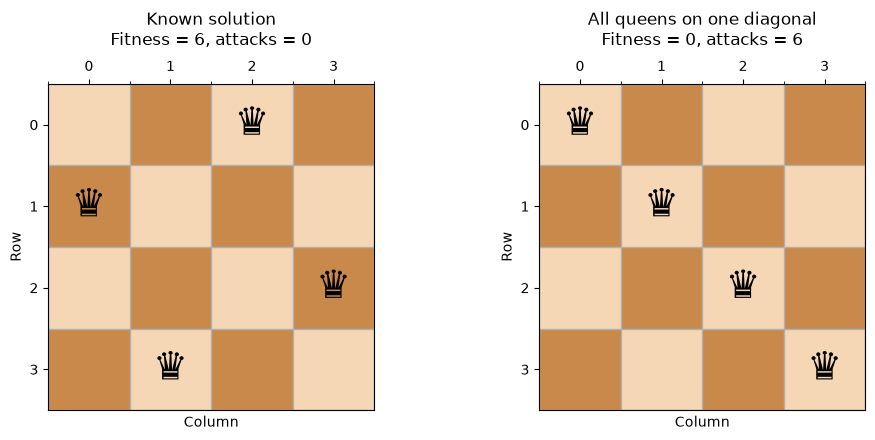

In [2]:
known_solution = [1, 3, 0, 2]
diagonal_board = [0, 1, 2, 3]

examples = [
    ("Known solution", known_solution),
    ("All queens on one diagonal", diagonal_board),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (label, permutation) in zip(axes, examples):
    draw_board(ax, permutation)
    ax.set_title(
        f"{label}\nFitness = {fitnessFunction(permutation)}, "
        f"attacks = {count_diagonal_attacks(permutation)}",
        pad=28,
    )

plt.tight_layout()
plt.show()

## Baseline 
### Hyperparameters
| Parameter | Value |
|---|---|
| Representation | Permutation |
| Recombination | Cut-and-Crossfill crossover |
| Recombination probability | 100% |
| Mutation | Swap mutation |
| Mutation probability | 80% per child |
| Parent selection | Best 2 out of a random tournament of 5 |
| Survival selection | Replace worst |
| Population size | 100 |
| Number of offspring | 2 per generation |
| Initialization | Random permutations |
| Termination condition | Solution found or 10,000 fitness evaluations |
| Optimal fitness | \(N(N-1)/2\) |

In [3]:
N_QUEENS = 8
MAX_FITNESS_EVALUATIONS = 10_000

Baseline configuration: {'population_size': 100, 'crossover_probability': 1.0, 'mutation_probability': 0.8, 'tournament_size': 5}
Best fitness: 28 / 28
Fitness evaluations: 444
Perfect solution found: True


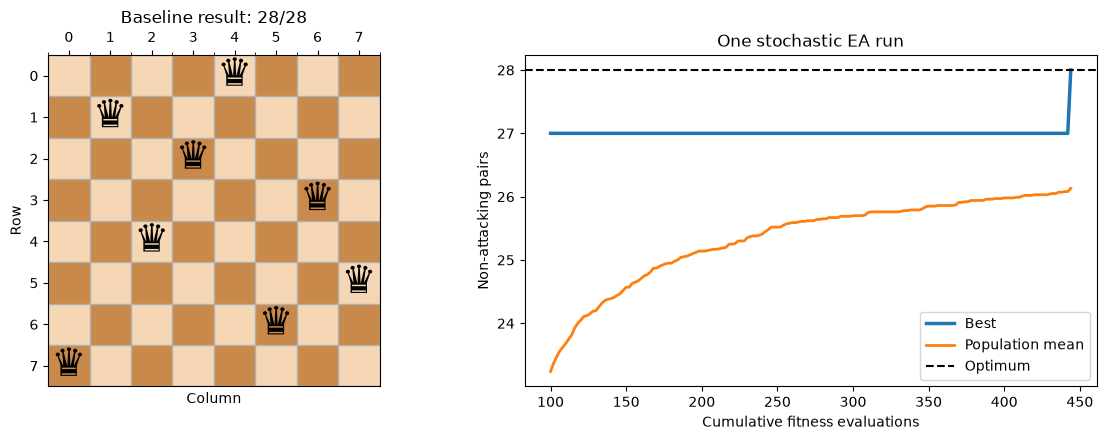

In [4]:
BASELINE = {
    "population_size": 100,
    "crossover_probability": 1.0,
    "mutation_probability": 0.8,
    "tournament_size": 5,
}
seed = 42
baseline_result = run_n_queens_ea(n_queens=N_QUEENS, **BASELINE, seed=seed)
optimum = N_QUEENS * (N_QUEENS - 1) // 2
print("Baseline configuration:", BASELINE)
print("Best fitness:", baseline_result["best_fitness"], "/", optimum)
print("Fitness evaluations:", baseline_result["evaluations"])
print("Perfect solution found:", bool(baseline_result["success"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
draw_board(
    axes[0],
    baseline_result["best_permutation"],
)
axes[0].set_title(f"Baseline result: {baseline_result['best_fitness']}/{optimum}")
baseline_history = baseline_result["history"]
axes[1].plot(
    baseline_history["evaluations"],
    baseline_history["best_fitness"],
    linewidth=2.5,
    label="Best",
)
axes[1].plot(
    baseline_history["evaluations"],
    baseline_history["mean_fitness"],
    linewidth=2,
    label="Population mean",
)
axes[1].axhline(optimum, color="black", linestyle="--", label="Optimum")
axes[1].set_xlabel("Cumulative fitness evaluations")
axes[1].set_ylabel("Non-attacking pairs")
axes[1].set_title("One stochastic EA run")
axes[1].legend()
plt.tight_layout()
plt.show()

## How utility is computed 

A configuration $A_i$ does not have one deterministic score. The EA uses random
initialization, selection, crossover, and mutation, so its performance is a random
variable. We estimate expected utility with $n$ independent runs:

$$\widehat U(A_i)=\frac{1}{n}\sum_{j=1}^{n}u(A_{i}^j,P).$$

where 

- $\widehat U(A_i)$ is the empirical estimate of utility 
- $n$ is the number of independent $A_i$ runs.
- $A_{i}^j$ represent the $j-th$ independent runt of $A_i$
- $M(A_{i}^{j})$ is the observed performance metric for that run



In [5]:
REPEATS = 2


def evaluate_configuration(params, *, method, configuration_id):
    rows = []
    for repeat in range(REPEATS):
        seed = repeat
        started = perf_counter()
        result = run_n_queens_ea(
            N_QUEENS,
            max_fitness_evaluations=MAX_FITNESS_EVALUATIONS,
            seed=seed,
            **params
        )
        elapsed = perf_counter() - started
        rows.append(
            {
                "method": method,
                "configuration_id": configuration_id,
                "repeat": repeat + 1,
                "seed": seed,
                **params,
                "best_fitness": result["best_fitness"],
                "evaluations": result["evaluations"],
                "elapsed_seconds": elapsed,
            }
        )
    return rows

In [6]:
BASELINE = {
    "population_size": 100,
    "crossover_probability": 1.0,
    "mutation_probability": 0.8,
    "tournament_size": 5,
}
seed = 42
runs = evaluate_configuration(BASELINE, method="Test", configuration_id=0)

In [7]:
pd.DataFrame(runs)

,method,configuration_id,repeat,seed,population_size,crossover_probability,mutation_probability,tournament_size,best_fitness,evaluations,elapsed_seconds
0,Test,0,1,0,100,1.0,0.8,5,28,472,0.015821
1,Test,0,2,1,100,1.0,0.8,5,28,482,0.014043


For a single run $A_i^j$, define three normalized performance components:
$$
\begin{aligned}
\text{quality}(A_i^j)
&= \frac{\text{best fitness}}{\binom{N}{2}}, \\[4pt]
\text{success}(A_i^j)
&= \mathbf{1}\left[\text{best fitness}=\binom{N}{2}\right], \\[4pt]
\text{efficiency}(A_i^j)
&= 1-\frac{\text{fitness evaluations used}}
{\text{maximum fitness evaluations}}.
\end{aligned}
$$


The observed performance metric for run $A_i^j$ is defined as the weighted utility:

$$
\begin{aligned}
M(A_i^j)
&= \lambda_1\,\text{quality}(A_i^j)
 + \lambda_2\,\text{success}(A_i^j)
 + \lambda_3\,\text{efficiency}(A_i^j).
\end{aligned}
$$

where

$$
\lambda_1,\lambda_2,\lambda_3 \geq 0,
\qquad
\lambda_1+\lambda_2+\lambda_3=1.
$$

Since all three components lie in $[0,1]$, the resulting performance metric also satisfies

$$
M(A_i^j) \in [0,1].
$$

### Weight Configuration

The weights $(\lambda_1,\lambda_2,\lambda_3)$ can be configured depending on the objective of the experiment.

For example, the default configuration

$$
(\lambda_1,\lambda_2,\lambda_3)=(0.75,0.20,0.05)
$$

places greater emphasis on solution quality while also considering success and computational efficiency.

Alternatively:

- **Quality only:** $(1,0,0)$
- **Success only:** $(0,1,0)$
- **Efficiency only:** $(0,0,1)$

Thus, the same metric $M(A_i^j)$ can be adapted to different experimental objectives by changing the weight vector.

In [8]:
# Utility is bounded by 0 and 1. The weights must sum to one.
UTILITY_WEIGHTS = {
    "quality": 0.75,
    "success": 0.20,
    "efficiency": 0.05,
}


def utility_components(result, *, n_queens, max_fitness_evaluations):
    """Convert one EA result into transparent, normalized utility components."""
    optimum = n_queens * (n_queens - 1) // 2
    quality = result["best_fitness"] / optimum
    success = float(result["success"])
    efficiency = max(
        0.0,
        1.0 - result["evaluations"] / max_fitness_evaluations,
    )
    utility = (
        UTILITY_WEIGHTS["quality"] * quality
        + UTILITY_WEIGHTS["success"] * success
        + UTILITY_WEIGHTS["efficiency"] * efficiency
    )
    return {
        "quality": quality,
        "success": success,
        "efficiency": efficiency,
        "utility": utility,
    }


def evaluate_configuration(params, *, method, configuration_id):
    rows = []
    for repeat in range(REPEATS):
        seed = repeat
        started = perf_counter()
        result = run_n_queens_ea(
            N_QUEENS,
            max_fitness_evaluations=MAX_FITNESS_EVALUATIONS,
            seed=seed,
            **params
        )
        elapsed = perf_counter() - started
        components = utility_components(
            result, n_queens=N_QUEENS, max_fitness_evaluations=MAX_FITNESS_EVALUATIONS
        )
        rows.append(
            {
                "method": method,
                "configuration_id": configuration_id,
                "repeat": repeat + 1,
                "seed": seed,
                **params,
                "best_fitness": result["best_fitness"],
                "evaluations": result["evaluations"],
                "elapsed_seconds": elapsed,
                **components,
            }
        )
    return rows

In [9]:
BASELINE = {
    "population_size": 100,
    "crossover_probability": 1.0,
    "mutation_probability": 0.8,
    "tournament_size": 5,
}
seed = 42
base_runs = evaluate_configuration(BASELINE, method="Test", configuration_id=0)
b_results = pd.DataFrame(base_runs)

In [10]:
b_results[
    [
        "repeat",
        "best_fitness",
        "evaluations",
        "quality",
        "success",
        "efficiency",
        "utility",
    ]
].round(4)

,repeat,best_fitness,evaluations,quality,success,efficiency,utility
0,1,28,472,1.0,1.0,0.9528,0.9976
1,2,28,482,1.0,1.0,0.9518,0.9976


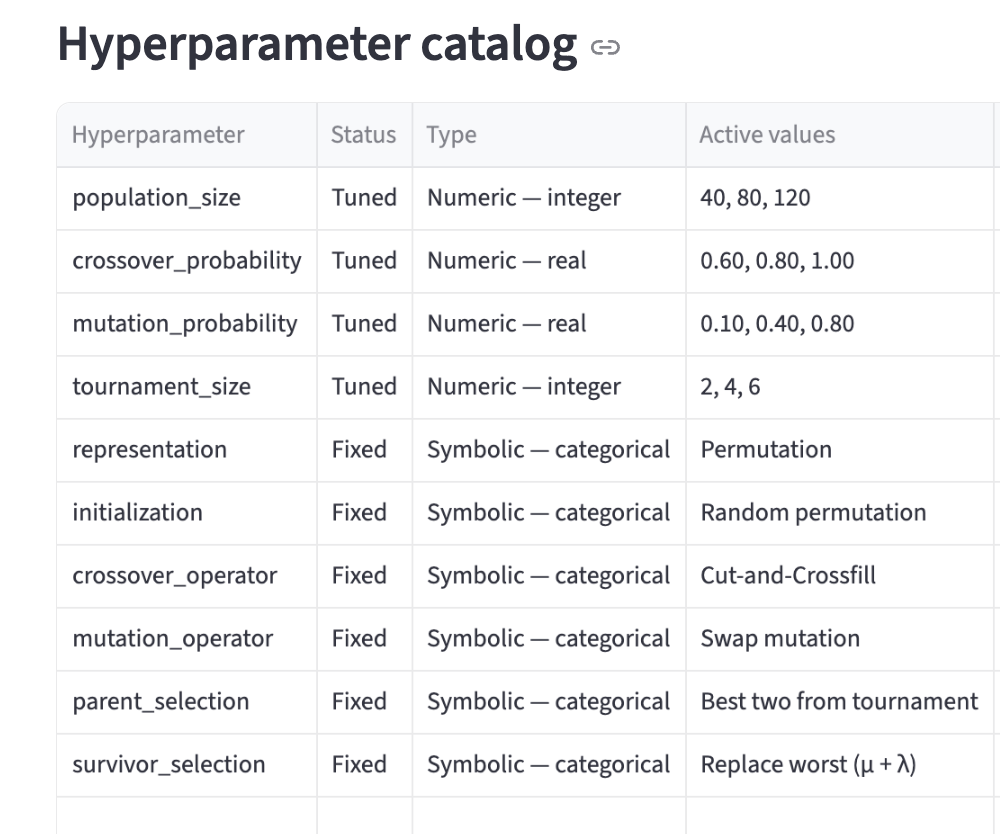

In [11]:
# Four three-level factors. Keeping discrete levels makes every design easy to inspect.
PARAMETER_SPACE = {
    "population_size": [40, 80, 120],
    "crossover_probability": [0.60, 0.80, 1.00],
    "mutation_probability": [0.10, 0.40, 0.80],
    "tournament_size": [2, 4, 6],
}

## Choose the search method to execute

Generate tuners: non-iterative and iterative
Non-iterative: executed onyl once during initializaiton 

### Initialization Methods
- Systematic grid/grid search
- Random sampling


### Grid Search

Grid search uses Python's `itertools.product()` function to generate the **Cartesian product** of the parameter values. This is equivalent to using nested `for` loops to evaluate every possible parameter combination.

For example, consider the following values:

$$
p_m \in [0.3, 0.8]
$$

and

$$
p_c \in [0.8, 1.0].
$$

The Cartesian product generates the following parameter vectors, written in the order $(p_m,p_c)$:

$$
\begin{aligned}
\theta_1 &= (0.3, 0.8), \\
\theta_2 &= (0.3, 1.0), \\
\theta_3 &= (0.8, 0.8), \\
\theta_4 &= (0.8, 1.0).
\end{aligned}
$$

Therefore, grid search evaluates **4 different parameter configurations**.

In Python, these combinations can be generated as follows:

```python
from itertools import product

pm_values = [0.3, 0.8]
pc_values = [0.8, 1.0]

parameter_grid = product(pm_values, pc_values)

for pm, pc in parameter_grid:
    print(pm, pc)
```

#### Example


In [12]:
PARAMETER_SPACE = {
    "crossover_probability": [0.6, 0.80, 1.0],
    "mutation_probability": [0.3, 0.6, 0.8],
}

In [13]:
# Generate parameter vectors
def grid(param_grid):

    param_combinations = list(itertools.product(*param_grid.values()))
    param_list = [dict(zip(param_grid.keys(), values)) for values in param_combinations]

    return param_list

In [14]:
grid_method = grid(param_grid=PARAMETER_SPACE)
grid_method

[{'crossover_probability': 0.6, 'mutation_probability': 0.3},
 {'crossover_probability': 0.6, 'mutation_probability': 0.6},
 {'crossover_probability': 0.6, 'mutation_probability': 0.8},
 {'crossover_probability': 0.8, 'mutation_probability': 0.3},
 {'crossover_probability': 0.8, 'mutation_probability': 0.6},
 {'crossover_probability': 0.8, 'mutation_probability': 0.8},
 {'crossover_probability': 1.0, 'mutation_probability': 0.3},
 {'crossover_probability': 1.0, 'mutation_probability': 0.6},
 {'crossover_probability': 1.0, 'mutation_probability': 0.8}]

> How many experiments will each method run?

In [15]:
print(f"{len(grid_method)} configurations")

9 configurations


In [16]:
import random


def randomSampling(param_grid, sample_size):
    param_combinations = grid(param_grid)
    total = len(param_combinations)

    # Proportion of the parameter space
    if isinstance(sample_size, float):
        if not 0 < sample_size < 1:
            raise ValueError("Float sample_size must be between 0 and 1.")

        sample_size = max(1, round(total * sample_size))

    # Exact number of experiments
    elif isinstance(sample_size, int):
        if sample_size <= 0:
            raise ValueError("Integer sample_size must be greater than 0.")

    else:
        raise TypeError("sample_size must be an int or a float.")

    # Do not sample more configurations than available
    sample_size = min(sample_size, total)

    return random.sample(param_combinations, sample_size)

In [17]:
random_method = randomSampling(PARAMETER_SPACE, 2)
random_method

[{'crossover_probability': 0.8, 'mutation_probability': 0.6},
 {'crossover_probability': 0.8, 'mutation_probability': 0.3}]

### Inspect one design per method

In [18]:
pd.DataFrame(grid_method)

,crossover_probability,mutation_probability
0,0.6,0.3
1,0.6,0.6
2,0.6,0.8
3,0.8,0.3
4,0.8,0.6
5,0.8,0.8
6,1.0,0.3
7,1.0,0.6
8,1.0,0.8


In [19]:
pd.DataFrame(random_method)

,crossover_probability,mutation_probability
0,0.8,0.6
1,0.8,0.3


## Run the search methods

In [20]:
def run_experiment(configurations, method="Random Sampling"):
    all_rows = []

    for i, params in enumerate(configurations, start=1):
        rows = evaluate_configuration(params, method=method, configuration_id=i)
        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    parameter_names = list(configurations[0].keys())

    summary = results.groupby(
        ["configuration_id"] + parameter_names, as_index=False
    ).agg(
        mean_utility=("utility", "mean"),
        mean_time=("elapsed_seconds", "mean"),
        total_time=("elapsed_seconds", "sum"),
    )

    # Best configuration
    best = summary.loc[summary["mean_utility"].idxmax()]

    print("\nBest configuration:")
    print(best)

    return summary, results

In [21]:
configurations = grid(PARAMETER_SPACE)

summary, results = run_experiment(configurations, method="Random Sampling")

summary


Best configuration:
configuration_id         6.000000
crossover_probability    0.800000
mutation_probability     0.800000
mean_utility             0.999340
mean_time                0.002164
total_time               0.004327
Name: 5, dtype: float64


,configuration_id,crossover_probability,mutation_probability,mean_utility,mean_time,total_time
0,1,0.6,0.3,0.998955,0.006580,0.013161
1,2,0.6,0.6,0.998917,0.006274,0.012548
2,3,0.6,0.8,0.998752,0.007528,0.015057
3,4,0.8,0.3,0.999267,0.002846,0.005693
4,5,0.8,0.6,0.998740,0.006554,0.013109
5,6,0.8,0.8,0.999340,0.002164,0.004327
6,7,1.0,0.3,0.998295,0.010372,0.020744
7,8,1.0,0.6,0.998930,0.005064,0.010128
8,9,1.0,0.8,0.997615,0.014538,0.029077
